<a href="https://colab.research.google.com/github/MO230101/Copolymer-lipid-interaction-study_ver.2/blob/main/%E3%80%87Savitzky_Goley_TDNMR_for_NC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_9356/932135862.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_smoothed[target_column] = signal.savgol_filter(df[target_column], window_length=window_length, polyorder=polyorder)
/tmp/ipykernel_9356/932135862.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_smoothed[target_column] = signal.savgol_filter(df[target_column], window_length=window_length, polyorder=polyorder)
/tmp/ipykernel_9356/932135862.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

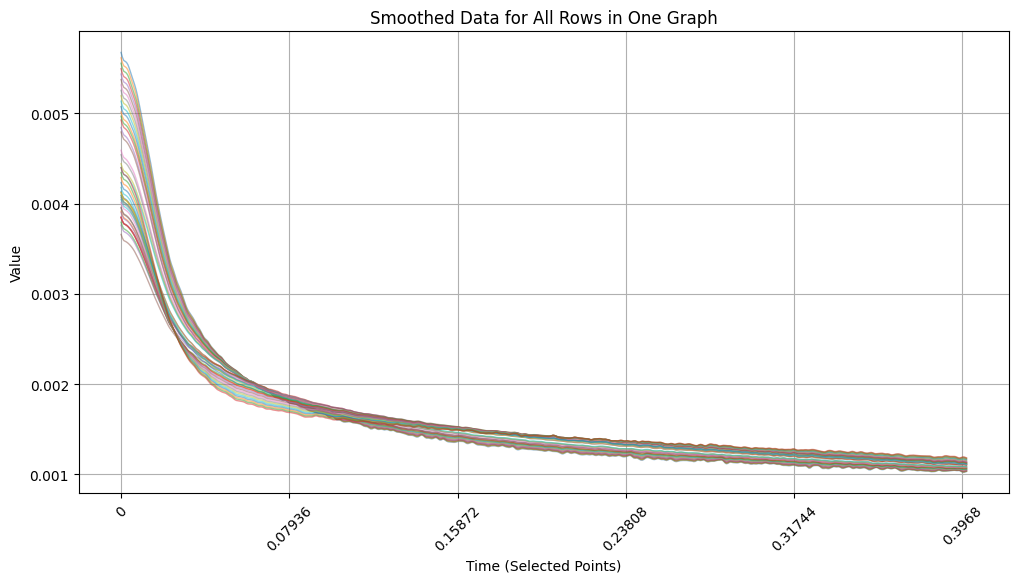

In [ ]:
import pandas as pd
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

# データを読み込む
df = pd.read_csv("AddD2O_MSE_T2relaxation_Relative_Intensity3.csv", index_col=0)

# Savitzky-Golay フィルタ設定
window_length = 23  # ウィンドウ長
polyorder = 1 # 多項式の次数

# 対象列を選択
target_columns = df.columns

# 処理データ保存用のDataFrame（元の列名を保持）
df_smoothed = pd.DataFrame(index=df.index)

# 各列にフィルタを適用
for target_column in target_columns:
    # NaN がある場合はスキップ
    if df[target_column].isnull().any():
        print(f"Skipping column '{target_column}' due to NaN values.")
        continue

    # Savitzky-Golay フィルタを適用
    df_smoothed[target_column] = signal.savgol_filter(df[target_column], window_length=window_length, polyorder=polyorder)

# CSV保存（元データの列名を維持）
df_smoothed.to_csv('smoothed_data_only.csv', index=True)

# すべての行を1つのグラフにプロット
plt.figure(figsize=(12, 6))
for idx in df_smoothed.index:
    plt.plot(df_smoothed.columns, df_smoothed.loc[idx], alpha=0.5, linewidth=1)  # 各行のデータを透明度0.5で表示

# X軸のラベルを5つに制限
num_xticks = 5
x_labels = df_smoothed.columns[::max(1, len(df_smoothed.columns) // num_xticks)]  # 均等に5つ選択
plt.xticks(x_labels, rotation=45)  # 適切な間隔でX軸のラベルを設定

plt.xlabel("Time (Selected Points)")
plt.ylabel("Value")
plt.title("Smoothed Data for All Rows in One Graph")
plt.grid(True)

plt.show()


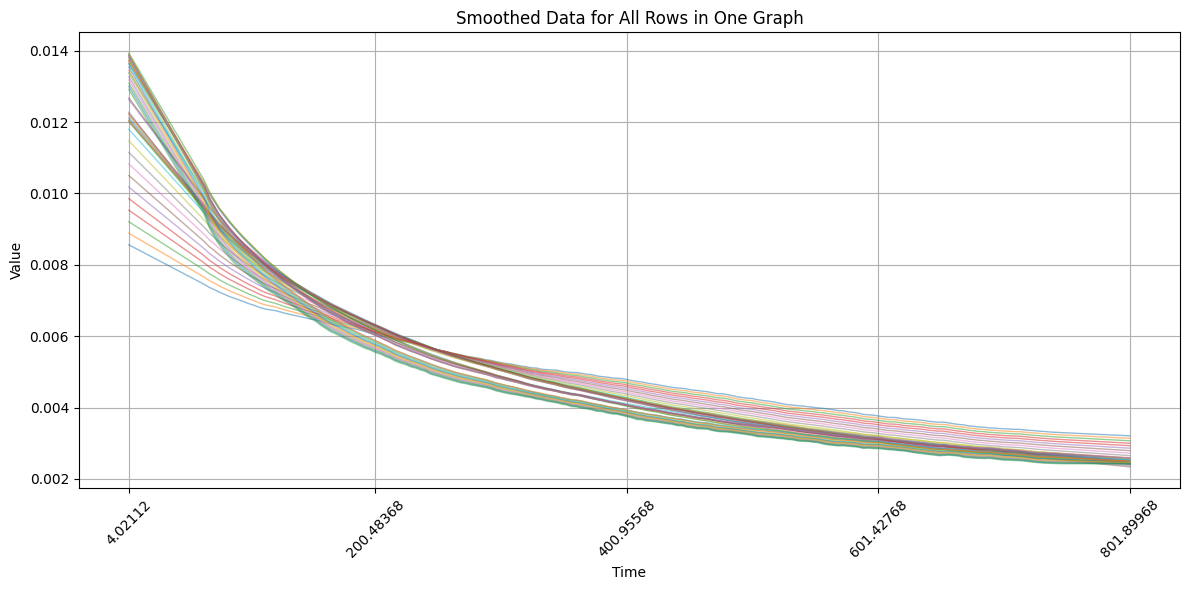

In [ ]:
import pandas as pd
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

# データを読み込む
df = pd.read_csv("AddD2O_CPMG_T2_Relative_Intensity_smoothed_44copolymers.csv", index_col=0)

# Savitzky-Golay フィルタ設定
window_length = 30
polyorder = 1

# window_length は奇数で、列数以下である必要がある
if window_length % 2 == 0:
    window_length += 1
if window_length > len(df.columns):
    window_length = len(df.columns) if len(df.columns) % 2 == 1 else len(df.columns) - 1

# 対象列を選択
target_columns = df.columns

# 処理データ保存用
df_smoothed = pd.DataFrame(index=df.index, columns=df.columns)

# 各行にフィルタを適用
for idx in df.index:
    row = df.loc[idx]

    # 重複indexがあると row が DataFrame になることがある
    if isinstance(row, pd.DataFrame):
        for sub_i in range(len(row)):
            y = row.iloc[sub_i].values.astype(float)

            if np.isnan(y).any():
                print(f"Skipping duplicated row '{idx}' due to NaN values.")
                continue

            y_smooth = signal.savgol_filter(y, window_length=window_length, polyorder=polyorder)
            df_smoothed.loc[f"{idx}__dup{sub_i+1}"] = y_smooth
    else:
        y = row.values.astype(float)

        if np.isnan(y).any():
            print(f"Skipping row '{idx}' due to NaN values.")
            continue

        y_smooth = signal.savgol_filter(y, window_length=window_length, polyorder=polyorder)
        df_smoothed.loc[idx] = y_smooth

# 空行削除
df_smoothed = df_smoothed.dropna(how="all")

# CSV保存
df_smoothed.to_csv("smoothed_data_only.csv", index=True)

# x軸を数値化
x = np.arange(len(df_smoothed.columns))

# プロット
plt.figure(figsize=(12, 6))
for i in range(len(df_smoothed)):
    plt.plot(x, df_smoothed.iloc[i].values.astype(float), alpha=0.5, linewidth=1)

# X軸ラベルを5個程度に間引く
num_xticks = 5
tick_idx = np.linspace(0, len(df_smoothed.columns)-1, num_xticks, dtype=int)
tick_labels = [df_smoothed.columns[i] for i in tick_idx]

plt.xticks(tick_idx, tick_labels, rotation=45)
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Smoothed Data for All Rows in One Graph")
plt.grid(True)
plt.tight_layout()
plt.show()